In [3]:
from backtest_engine import request, Portfolio, PortfolioDynamicCost, StrategyConnector, generate_toy_equity
from datetime import date
import tomllib

with open("config.toml", "rb") as f:
    config = tomllib.load(f)["alpaca-api"]
    
df = request(
    ticker="SPY",
    config=config,
)

# todo: optimise pd -> np
# todo: consider refactoring tearsheet and connector into dataclasses

Loading data from local cache: cache_SPY_20170101_20260620.parquet


In [ ]:
p = PortfolioDynamicCost(df)

toy_book = generate_toy_equity(p, expected_return=0.15, volatility=0.075)

c = StrategyConnector(p, toy_book, df["close"])

print(p.result(decompose=True)) 
print(p.result(start=date(2020, 1, 1), end=date(2021, 1, 1)))
print(p.result(day=date(2025, 4, 12)))


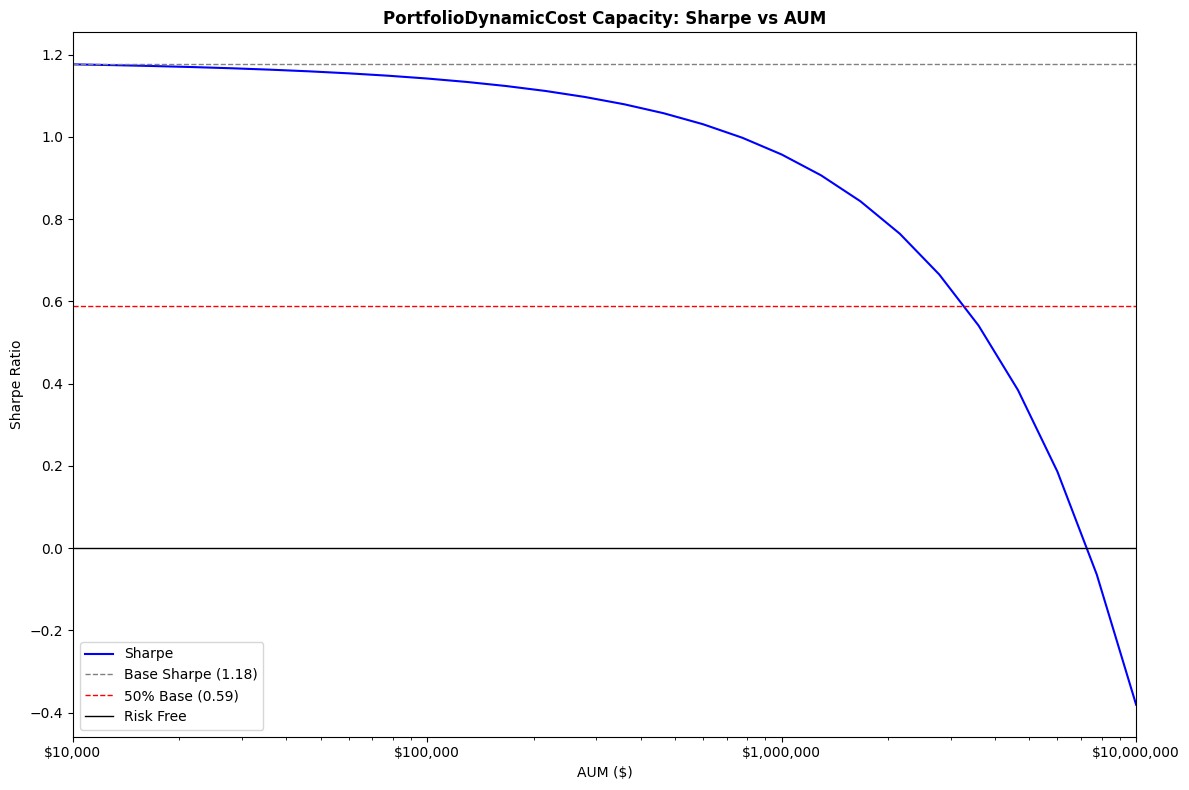

In [ ]:
PortfolioDynamicCost.sharpe_curve(df, max_aum=10_000_000)

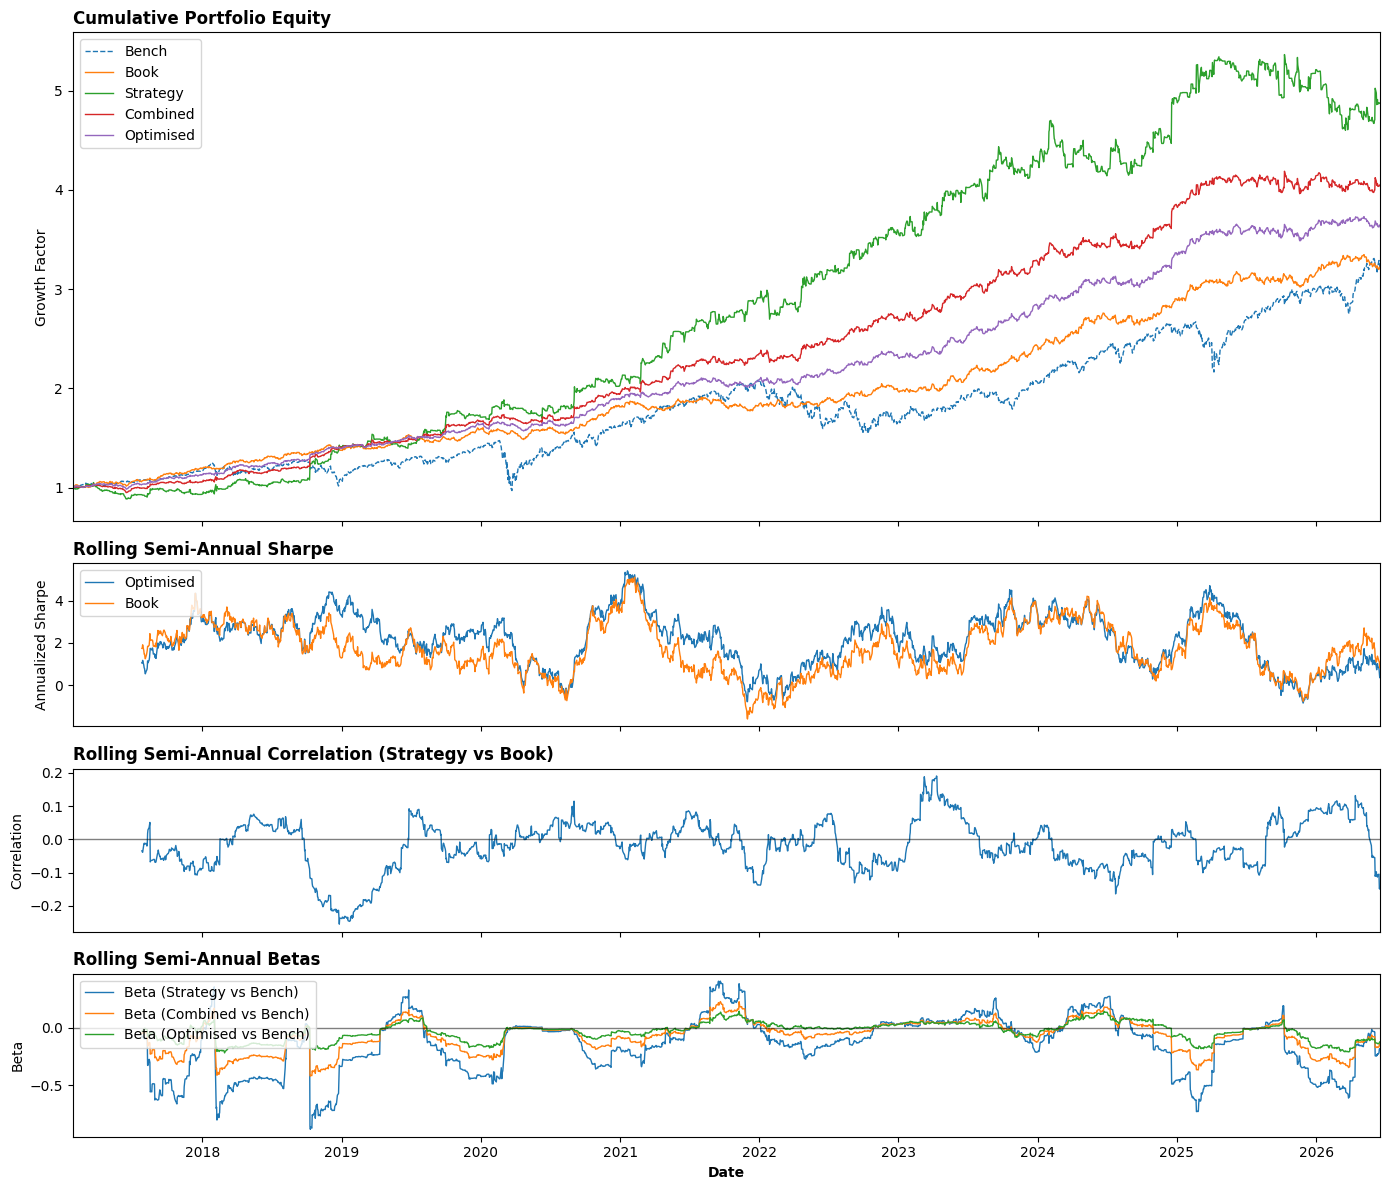

=== Portfolio Integration & Risk Report ===
                                Book Strategy   Combined Optimised    Bench
Expected Return               12.75%   18.17%     15.30%    14.02%   14.30%
Volatility                     7.56%   16.07%      8.79%     6.84%   18.45%
Sharpe                          1.69     1.13       1.74      2.05     0.77
Beta                            0.00    -0.10      -0.05     -0.02     1.00
Skewness                       -0.03     2.58       1.73      0.28    -0.36
Kurtosis                        0.06    20.65      12.47      1.26    14.94
Max Drawdown                  -7.46%  -15.81%     -8.48%    -5.57%  -34.23%
Max DD Days                      260      255        172       144      512
Max DD Recovery Days              47      195         56        20      103
Correlation to Book                -    -0.03       0.40      0.82        -
Crash Correlation to Book          -    -0.04       0.16      0.51        -
Intraday Correlation to Book       -    -0.0

In [ ]:
c.result()